##Assignment 1: Single Layer Perception

###Import libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

###Load CSV files

In [37]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")

print("Training CSV shape:", train_df.shape)
print("Validation CSV shape:", val_df.shape)

Training CSV shape: (410, 24)
Validation CSV shape: (112, 21)


###Prepare training data

In [38]:
X_train = train_df.iloc[3:83, 2:6].astype(float).values
y_train = train_df.iloc[3:83, 6].astype(float).values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (80, 4)
y_train shape: (80,)


###Prepare validation data

In [39]:
X_val = val_df.iloc[5:25, 2:6].astype(float).values
y_val = val_df.iloc[5:25, 6].astype(float).values

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

X_val shape: (20, 4)
y_val shape: (20,)


###Set initial parameters

In [40]:
number_of_epochs = 5
training_samples_per_epoch = 80
validation_samples_per_epoch = 20

In [41]:
learning_rate = 0.1

initial_weights = np.array(
    [0.5, 0.5, 0.5, 0.5],
    dtype=float
)

initial_bias = 0.5

###Define sigmoid function

In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [43]:
print(sigmoid(0))

0.5


###Prepare Storage for Results

In [44]:
train_accuracy_history = []
validation_accuracy_history = []

train_mse_history = []
validation_mse_history = []

###Train the SLP & Validate the SLP

In [45]:
# TRAINING AND VALIDATION

weights = initial_weights.copy()
bias = initial_bias

for epoch in range(number_of_epochs):

    print("=" * 50)
    print(f"Epoch {epoch + 1}")
    print("=" * 50)

    train_start = 3 + (epoch * training_samples_per_epoch)
    train_end = train_start + training_samples_per_epoch

    train_data = train_df.iloc[
        train_start:train_end, 2:7
    ].astype(float).values

    X_train = train_data[:, 0:4]
    y_train = train_data[:, 4]

    val_start = 5 + (epoch * validation_samples_per_epoch)
    val_end = val_start + validation_samples_per_epoch

    val_data = val_df.iloc[
        val_start:val_end, 2:7
    ].astype(float).values

    X_val = val_data[:, 0:4]
    y_val = val_data[:, 4]

    # Training

    train_squared_errors = []
    correct_train = 0

    for i in range(len(X_train)):

        x_i = X_train[i]
        y_i = y_train[i]

        z = np.dot(x_i, weights) + bias
        g_z = sigmoid(z)

        prediction = 1 if g_z >= 0.5 else 0

        if prediction == y_i:
            correct_train += 1

        error = g_z - y_i
        train_squared_errors.append(error ** 2)

        g_prime = g_z * (1 - g_z)

        d_bias = 2 * error * g_prime
        d_weights = 2 * error * g_prime * x_i

        bias -= learning_rate * d_bias
        weights -= learning_rate * d_weights

    train_accuracy = correct_train / len(X_train)
    train_mse = np.mean(train_squared_errors)

    train_accuracy_history.append(train_accuracy)
    train_mse_history.append(train_mse)

    # Validation

    val_squared_errors = []
    correct_val = 0

    val_weights = weights.copy()
    val_bias = bias

    for i in range(len(X_val)):

        x_i = X_val[i]
        y_i = y_val[i]

        z = np.dot(x_i, val_weights) + val_bias
        g_z = sigmoid(z)

        prediction = 1 if g_z >= 0.5 else 0

        if prediction == y_i:
            correct_val += 1

        error = g_z - y_i
        val_squared_errors.append(error ** 2)

    validation_accuracy = correct_val / len(X_val)
    validation_mse = np.mean(val_squared_errors)

    validation_accuracy_history.append(validation_accuracy)
    validation_mse_history.append(validation_mse)


    # Display results
    print(f"Training Accuracy   : {train_accuracy:.4f}")
    print(f"Training MSE        : {train_mse:.10f}")
    print(f"Validation Accuracy : {validation_accuracy:.4f}")
    print(f"Validation MSE      : {validation_mse:.10f}")
    print()

Epoch 1
Training Accuracy   : 0.5250
Training MSE        : 0.4498886551
Validation Accuracy : 0.5000
Validation MSE      : 0.3289511566

Epoch 2
Training Accuracy   : 0.9500
Training MSE        : 0.0374519142
Validation Accuracy : 0.5000
Validation MSE      : 0.2472893233

Epoch 3
Training Accuracy   : 0.9750
Training MSE        : 0.0243721950
Validation Accuracy : 0.5000
Validation MSE      : 0.1758916407

Epoch 4
Training Accuracy   : 0.9750
Training MSE        : 0.0173572017
Validation Accuracy : 0.8500
Validation MSE      : 0.1193813733

Epoch 5
Training Accuracy   : 0.9875
Training MSE        : 0.0127401582
Validation Accuracy : 1.0000
Validation MSE      : 0.0815813694



###Display accuracy results

In [51]:
accuracy_results = pd.DataFrame({
    "Epoch": range(1, number_of_epochs + 1),
    "Training Accuracy": train_accuracy_history,
    "Validation Accuracy": validation_accuracy_history
})

display(accuracy_results)

,Epoch,Training Accuracy,Validation Accuracy
0,1,0.5250,0.50
1,2,0.9500,0.50
2,3,0.9750,0.50
3,4,0.9750,0.85
4,5,0.9875,1.00


###Display loss/MSE results

In [47]:
loss_results = pd.DataFrame({
    "Epoch": range(1, number_of_epochs + 1),
    "Training MSE": train_mse_history,
    "Validation MSE": validation_mse_history
})

display(loss_results)

,Epoch,Training MSE,Validation MSE
0,1,0.449889,0.328951
1,2,0.037452,0.247289
2,3,0.024372,0.175892
3,4,0.017357,0.119381
4,5,0.012740,0.081581


###Plot accuracy

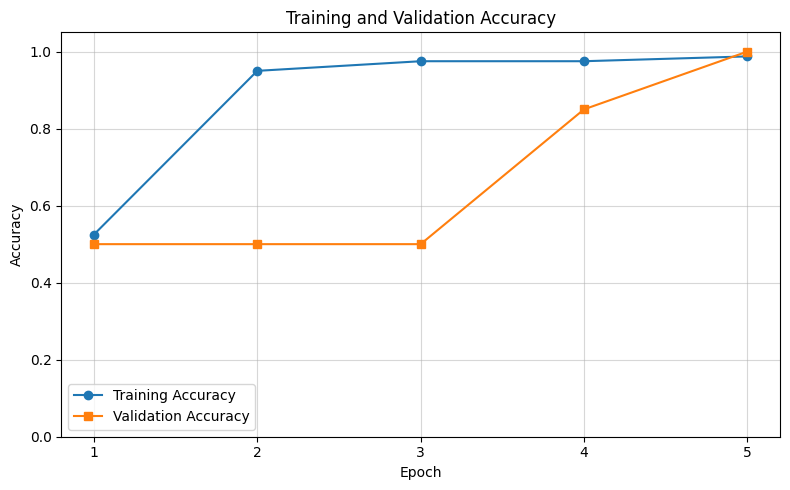

In [48]:
epochs_range = range(1, number_of_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracy_history,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    validation_accuracy_history,
    marker="s",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.xticks(epochs_range)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.5)
plt.legend()

plt.tight_layout()

plt.show()

###Plot loss

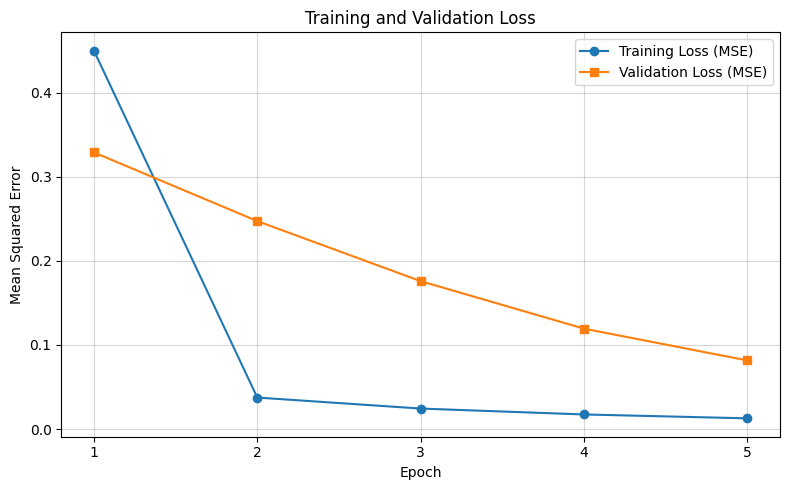

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_mse_history,
    marker="o",
    label="Training Loss (MSE)"
)

plt.plot(
    epochs_range,
    validation_mse_history,
    marker="s",
    label="Validation Loss (MSE)"
)

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")

plt.xticks(epochs_range)

plt.grid(True, alpha=0.5)
plt.legend()

plt.tight_layout()

plt.show()

###Save results

In [50]:
final_results = pd.DataFrame({
    "Epoch": range(1, number_of_epochs + 1),
    "Training Accuracy": train_accuracy_history,
    "Validation Accuracy": validation_accuracy_history,
    "Training MSE": train_mse_history,
    "Validation MSE": validation_mse_history
})

final_results.to_csv(
    "perceptron_results.csv",
    index=False
)

print("Results saved as perceptron_results.csv")

Results saved as perceptron_results.csv
